# 1. Compare Models
# 2. Feature importance Analysis

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

## 1.2. Model groups=1,2,3,4

In [8]:
df_g1234 = pd.read_csv('output_model_G1234_avrg.csv')
df_g1234.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
0,7.864709,7.536908,7.472138,7.134642,7.787520,7.559184,7.886057,-4.144949
1,5.463920,5.294245,5.503187,5.683762,5.322797,5.453582,5.769551,-5.476488
2,7.298016,7.409103,7.361859,7.250291,7.717104,7.407275,7.244125,2.252164
3,5.562703,5.488126,5.397657,4.962770,5.530093,5.388270,5.387216,0.019560


## 1.3. ## 1.2. Model groups=1,2,3

In [9]:
df_g123 = pd.read_csv('output_model_G123_avrg.csv')
df_g123.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
0,7.660323,7.463790,7.686842,7.526644,7.727900,7.613100,7.886057,-3.461262
1,5.153248,5.370785,5.440676,5.201054,5.080816,5.249316,5.769551,-9.016912
2,7.435029,7.003176,7.371014,7.403513,7.283821,7.299310,7.244125,0.761791
3,5.365249,5.526660,5.672641,5.213118,5.397713,5.435076,5.387216,0.888392


## 1.4. Model groups=1,2

In [10]:
df_g12 = pd.read_csv('output_model_G12_avrg.csv')
df_g12.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
0,7.709640,7.518972,7.644924,7.631299,7.665178,7.634003,7.886057,-3.196198
1,5.621986,5.264903,5.260285,5.321470,5.267072,5.347144,5.769551,-7.321322
2,7.483162,7.346616,7.327475,7.507686,7.287429,7.390474,7.244125,2.020240
3,5.248728,5.477678,5.627798,5.351416,5.439092,5.428942,5.387216,0.774538


## 1.4. Model group=1

In [11]:
df_g1 = pd.read_csv('output_model_G1_avrg.csv')
df_g1.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
0,7.253723,7.428530,7.775692,7.415351,7.632143,7.501088,7.886057,-4.881635
1,5.161010,4.941776,5.207817,5.225940,4.975024,5.102313,5.769551,-11.564817
2,7.081150,7.207612,7.066239,7.372579,7.134966,7.172510,7.244125,-0.988601
3,5.143604,5.593310,5.701962,5.274138,5.436477,5.429898,5.387216,0.792285


# Model all descriptors

In [13]:
df_2d = pd.read_csv('V2-output_model_2d_3d_fp_all_avrg_pic50.csv')
df_2d.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test,Relative_Error_%
0,7.481468,7.801305,7.753548,7.593038,7.928951,7.711662,7.886057,-2.211427
1,5.285185,5.330835,5.167536,5.297995,5.461863,5.308683,5.769551,-7.987938
2,7.237749,7.538920,7.103492,7.485972,7.379383,7.349103,7.244125,1.449144
3,5.105734,5.504673,5.491929,5.502547,5.387544,5.398486,5.387216,0.209190


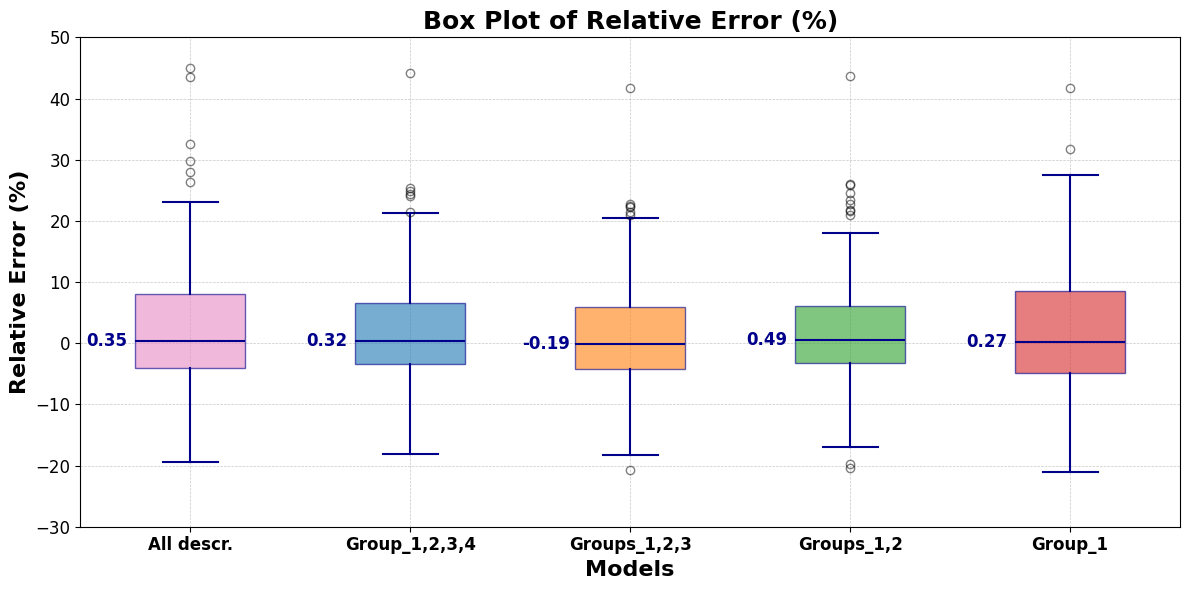

In [19]:
# Reset the index of the DataFrames
df_g1.reset_index(drop=True, inplace=True)
df_g12.reset_index(drop=True, inplace=True)
df_g123.reset_index(drop=True, inplace=True)
df_g1234.reset_index(drop=True, inplace=True)
df_g12345.reset_index(drop=True, inplace=True)

df_2d.reset_index(drop=True, inplace=True)

log_target_2d = df_2d['Relative_Error_%']
log_target_a = df_g1['Relative_Error_%']
log_target_b = df_g12['Relative_Error_%']
log_target_c = df_g123['Relative_Error_%']
log_target_d = df_g1234['Relative_Error_%']
#log_target_e = df_g12345['Relative_Error_%']

plt.figure(figsize=(12, 6))

# Create the box plot for all four datasets
box = plt.boxplot([log_target_2d, log_target_d, log_target_c, log_target_b, log_target_a], vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='none', color='darkblue'),
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the colors of the boxes
colors = ['#e78ac3', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=18, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=16, weight='bold')
plt.xlabel('Models', fontsize=16, weight='bold')
plt.xticks([1, 2, 3, 4, 5], ['All descr.', 'Group_1,2,3,4', 'Groups_1,2,3', 'Groups_1,2', 'Group_1'], fontsize=12, weight='bold')

# Adding median values as text
medians = [median.get_ydata()[0] for median in box['medians']]
for median, x in zip(medians, range(1, len(medians) + 1)):
    plt.text(x - 0.38, median, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=12)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim(-30, 50)  # Set y-axis limit from -50 to 200
plt.tight_layout()

# Display the plot
plt.show()

In [20]:
from scipy import stats
import pandas as pd

# Perform t-tests for the pairs: 1a-1b, 1a-1c, 1c-1d
t_test_results = {
    "2d vs G1": stats.ttest_ind(df_2d['Relative_Error_%'], df_g1['Relative_Error_%'], equal_var=False),
    "2d vs G12": stats.ttest_ind(df_2d['Relative_Error_%'], df_g12['Relative_Error_%'], equal_var=False),    
    "2d vs G123": stats.ttest_ind(df_2d['Relative_Error_%'], df_g123['Relative_Error_%'], equal_var=False),
    "2d vs G1234": stats.ttest_ind(df_2d['Relative_Error_%'], df_g1234['Relative_Error_%'], equal_var=False)
}

# Print the results
for pair, result in t_test_results.items():
    print(f"T-test for {pair}:")
    print(f"  t-statistic: {result.statistic:.3f}")
    print(f"  p-value: {result.pvalue:.3f}\n")


T-test for 2d vs G1:
  t-statistic: 0.744
  p-value: 0.457

T-test for 2d vs G12:
  t-statistic: 0.457
  p-value: 0.648

T-test for 2d vs G123:
  t-statistic: 0.972
  p-value: 0.332

T-test for 2d vs G1234:
  t-statistic: 0.347
  p-value: 0.729



# II. Augmented dataset:

In [21]:
df_aug = pd.read_csv('V2-output_model_aug_gr123.csv')
df_aug.head(4)

,y_pred_run_1,y_pred_run_2,y_pred_run_3,y_pred_run_4,y_pred_run_5,average_y_pred,y_test_val,Relative_Error_%
0,5.077712,5.146285,5.324062,4.985079,5.224190,5.151465,5.244125,-1.766924
1,5.709779,5.400370,5.621474,5.987589,5.408631,5.625568,5.853872,-3.900044
2,5.454774,6.135907,6.089284,6.074410,6.158813,5.982638,5.995679,-0.217502
3,6.524003,6.976379,6.884429,6.621428,7.033159,6.807879,6.372634,6.829912


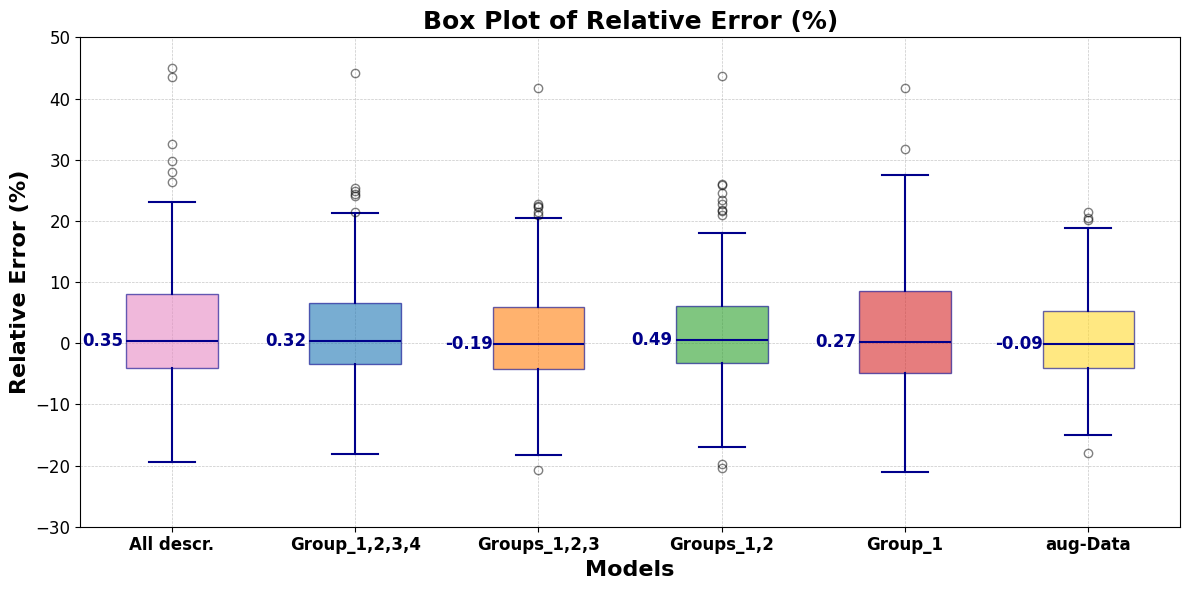

In [26]:
# Reset the index of the DataFrames
df_g1.reset_index(drop=True, inplace=True)
df_g12.reset_index(drop=True, inplace=True)
df_g123.reset_index(drop=True, inplace=True)
df_g1234.reset_index(drop=True, inplace=True)
df_g12345.reset_index(drop=True, inplace=True)

df_2d.reset_index(drop=True, inplace=True)
df_aug.reset_index(drop=True, inplace=True)

log_target_2d = df_2d['Relative_Error_%']
log_target_a = df_g1['Relative_Error_%']
log_target_b = df_g12['Relative_Error_%']
log_target_c = df_g123['Relative_Error_%']
log_target_d = df_g1234['Relative_Error_%']
log_target_e = df_aug['Relative_Error_%']

plt.figure(figsize=(12, 6))

# Create the box plot for all four datasets
box = plt.boxplot([log_target_2d, log_target_d, log_target_c, log_target_b, log_target_a, log_target_e], vert=True, patch_artist=True, 
                  boxprops=dict(facecolor='none', color='darkblue'),
                  medianprops=dict(color='darkblue', linewidth=1.5), 
                  whiskerprops=dict(color='darkblue', linewidth=1.5),
                  capprops=dict(color='darkblue', linewidth=1.5), 
                  flierprops=dict(marker='o', color='red', alpha=0.5))

# Change the colors of the boxes
colors = ['#e78ac3', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#ffd92f']
for box_patch, color in zip(box['boxes'], colors):
    box_patch.set(facecolor=color, alpha=0.6)

# Add grid lines
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add a title and labels with custom font sizes
plt.title('Box Plot of Relative Error (%)', fontsize=18, weight='bold')
plt.ylabel('Relative Error (%)', fontsize=16, weight='bold')
plt.xlabel('Models', fontsize=16, weight='bold')
plt.xticks([1, 2, 3, 4, 5, 6], ['All descr.', 'Group_1,2,3,4', 'Groups_1,2,3', 'Groups_1,2', 'Group_1', 'aug-Data'], fontsize=12, weight='bold')

# Adding median values as text
medians = [median.get_ydata()[0] for median in box['medians']]
for median, x in zip(medians, range(1, len(medians) + 1)):
    plt.text(x - 0.38, median, f'{median:.2f}', horizontalalignment='center', color='darkblue', weight='semibold', va='center', fontsize=12)

# Enhance the appearance of the plot
plt.tick_params(axis='both', which='major', labelsize=12)
plt.ylim(-30, 50)  # Set y-axis limit from -50 to 200
plt.tight_layout()

# Display the plot
plt.show()

In [24]:
from scipy import stats
import pandas as pd

# Perform t-tests for the pairs: 1a-1b, 1a-1c, 1c-1d
t_test_results = {
    "2d vs G1": stats.ttest_ind(df_2d['Relative_Error_%'], df_g1['Relative_Error_%'], equal_var=False),
    "2d vs G12": stats.ttest_ind(df_2d['Relative_Error_%'], df_g12['Relative_Error_%'], equal_var=False),    
    "2d vs G123": stats.ttest_ind(df_2d['Relative_Error_%'], df_g123['Relative_Error_%'], equal_var=False),
    "2d vs G1234": stats.ttest_ind(df_2d['Relative_Error_%'], df_g1234['Relative_Error_%'], equal_var=False),
    "2d vs Aug-db": stats.ttest_ind(df_2d['Relative_Error_%'], df_aug['Relative_Error_%'], equal_var=False)
}

# Print the results
for pair, result in t_test_results.items():
    print(f"T-test for {pair}:")
    print(f"  t-statistic: {result.statistic:.3f}")
    print(f"  p-value: {result.pvalue:.3f}\n")


T-test for 2d vs G1:
  t-statistic: 0.744
  p-value: 0.457

T-test for 2d vs G12:
  t-statistic: 0.457
  p-value: 0.648

T-test for 2d vs G123:
  t-statistic: 0.972
  p-value: 0.332

T-test for 2d vs G1234:
  t-statistic: 0.347
  p-value: 0.729

T-test for 2d vs Aug-db:
  t-statistic: 1.200
  p-value: 0.232

